## First Implementation of the TFT with only Macro Variables

### Inspecting & Importing Data

In [9]:
import pytorch_forecasting
import pandas as pd
import os
import matplotlib as plt

In [6]:
# os.getcwd()
monthly_path = '/Users/minna/Code/FS26/AML/aml2026-group-3/data/macro-vars-monthly.csv'
df_monthly = pd.read_csv(monthly_path)
df_monthly = df_monthly.rename(columns = {'Unnamed: 0':'date'})
df_monthly['date'] = pd.to_datetime(df_monthly['date'])
print(df_monthly.tail(10))

           date      CPI    PCEPI    PAYEMS  JTSJOL  UMCSENT    INDPRO
1277 2025-06-01  321.435  126.743  158478.0  7204.0     60.7  101.4785
1278 2025-07-01  322.169  126.960  158542.0  7089.0     61.7  101.8940
1279 2025-08-01  323.291  127.293  158472.0  6919.0     58.2  101.6247
1280 2025-09-01  324.245  127.625  158548.0  7169.0     55.1  101.6680
1281 2025-10-01      NaN  127.871  158408.0  7170.0     53.6  101.2075
1282 2025-11-01  325.063  128.152  158449.0  6846.0     51.0  101.3605
1283 2025-12-01  326.031  128.576  158432.0  6550.0     52.9  101.6781
1284 2026-01-01  326.588  128.965  158592.0  7240.0     56.4  102.3963
1285 2026-02-01  327.460  129.449  158459.0  6882.0     56.6  102.5510
1286 2026-03-01  330.293      NaN  158637.0     NaN      NaN       NaN


In [7]:
print(df_monthly.info())

<class 'pandas.DataFrame'>
RangeIndex: 1287 entries, 0 to 1286
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     1287 non-null   datetime64[us]
 1   CPI      950 non-null    float64       
 2   PCEPI    806 non-null    float64       
 3   PAYEMS   1047 non-null   float64       
 4   JTSJOL   303 non-null    float64       
 5   UMCSENT  670 non-null    float64       
 6   INDPRO   1286 non-null   float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 70.5 KB
None


array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>], dtype=object)

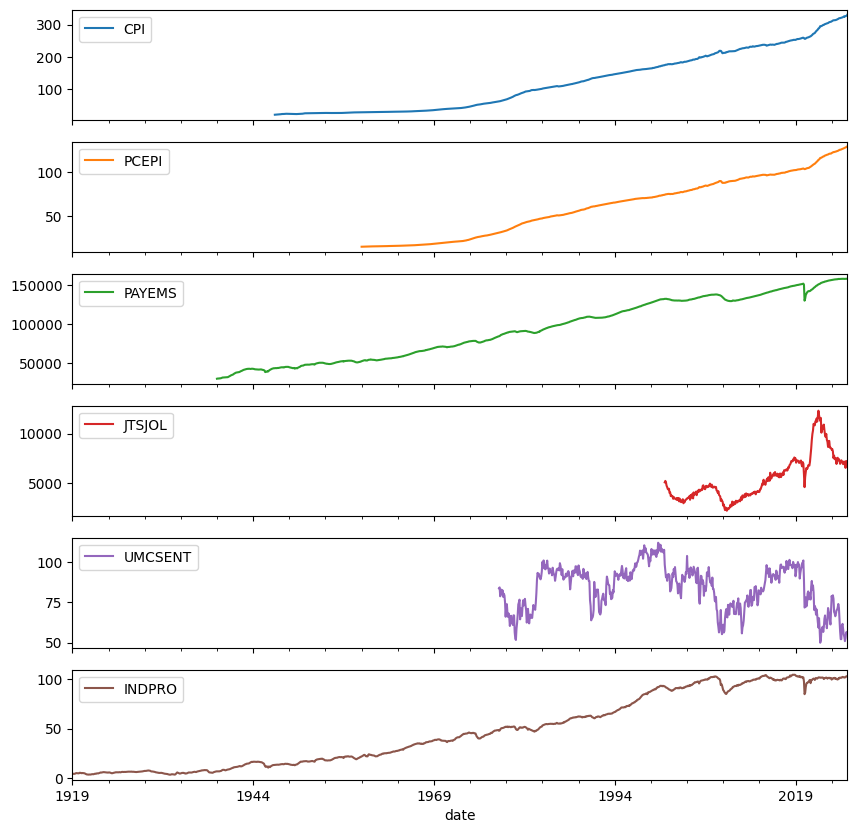

In [ ]:
# basic plot to inspect length
df_monthly.plot(x='date', y=['CPI', 'PCEPI', 'PAYEMS', 'JTSJOL', 'UMCSENT', 'INDPRO'], subplots=True, figsize=(10, 10))

#### Meaning of Variables:

**CPI** -> Consumer Price Index 
**PCEPI** -> Personal Consumption Expenditures Price Index 
**PAYEMS** -> Total Nonfarm Payrolls
**JTSJOL** -> Job Openings: Total Nonfarm (non-farm workers)
**UMCSENT** -> University of Michigan Sentiment Index
**INDPRO** -> Industrial Production Index

### Implementing TFT

**Info on Model**, based on the following paper: [Temporal Fusion Transformers for Interpretable Multi-horizon Time Series Forecasting](https://arxiv.org/abs/1912.09363)


The TFT should handle single or multiple targets and a whole lot of different covariates such as:

- *static covariates*: these are the ones that do not change through the course of the timeseries. In our case we have country, publication source, etc.  
    - could potentially fetch information from [FRED Website on the different variables](https://fred.stlouisfed.org/series/PAYEMS) for more static covariates? 

- *time series covariates*, they actually belong to 2 different groups:

    - known in advance: such as day_of_the_week, month, holidays, etc.

    - unknown in advance: f.i. if we hade the stock level for each product, we would know it just in the past

